In [24]:
import pandas as pd
import seaborn as sns

from scipy.stats import kruskal
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [25]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week1

C:\Users\tr432\Downloads\filter_GutLungAxis_Week1


In [26]:
## qzv 파일 Qiime2View에 넣고 'Download raw data as TSV' 로 다운받은 후 파일명만 바꿔서 사용
df_faithpd = pd.read_csv('faith.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'faith_pd'])
df_observed = pd.read_csv('observed.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'observed_features'])
df_shannon = pd.read_csv('shannon.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'shannon_entropy'])
df_pielou = pd.read_csv('pielou.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'pielou_evenness'])
df_ace = pd.read_csv('ace.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'ace'])
df_chao1 = pd.read_csv('chao1.tsv', sep='\t', skiprows=[1], usecols=['id', 'Group', 'chao1'])
df_simpson = pd.read_csv('simpson.tsv', sep='\t', skiprows=[1]
                         , usecols=['id', 'Group', 'functools.partial(<function _simpsons_dominance at 0x75cdef3dc310>)'])  #Edit

print(df_faithpd.head(3))
print(df_observed.head(3))
print(df_shannon.head(3))
print(df_pielou.head(3))
print(df_ace.head(3))
print(df_chao1.head(3))
print(df_simpson.head(3))

       id    Group   faith_pd
0  C01-1w  Control  20.335410
1  C02-1w  Control  20.374461
2  C03-1w  Control  19.292829
       id    Group  observed_features
0  C01-1w  Control                311
1  C02-1w  Control                345
2  C03-1w  Control                295
       id    Group  shannon_entropy
0  C01-1w  Control         6.708522
1  C02-1w  Control         6.660730
2  C03-1w  Control         5.541440
       id    Group  pielou_evenness
0  C01-1w  Control         0.807010
1  C02-1w  Control         0.787836
2  C03-1w  Control         0.675059
       id    Group  ace
0  C01-1w  Control  315
1  C02-1w  Control  355
2  C03-1w  Control  300
       id    Group  chao1
0  C01-1w  Control    315
1  C02-1w  Control    355
2  C03-1w  Control    300
       id    Group  \
0  C01-1w  Control   
1  C02-1w  Control   
2  C03-1w  Control   

   functools.partial(<function _simpsons_dominance at 0x75cdef3dc310>)  
0                                           0.982683                    
1    

In [27]:
## Group 종류 확인
print(df_faithpd.Group.unique())
print(df_observed.Group.unique())
print(df_shannon.Group.unique())
print(df_pielou.Group.unique())
print(df_ace.Group.unique())
print(df_chao1.Group.unique())
print(df_simpson.Group.unique())

['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']
['Control' 'VNAM']


Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


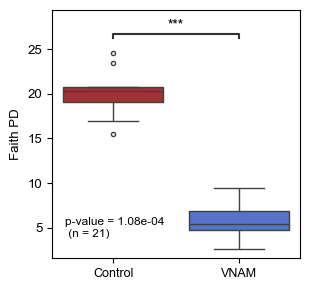

In [28]:
## Faith PD


data = df_faithpd
feat = data.columns[2]  ## Group 열 의미함
orders = data.Group.unique()  ## Group 종류 의미함

Control = data[data['Group'] == 'Control']['faith_pd']  #Edit
VNAM = data[data['Group'] == 'VNAM']['faith_pd']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(0, 175)
plt.ylabel('Faith PD', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('faith.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


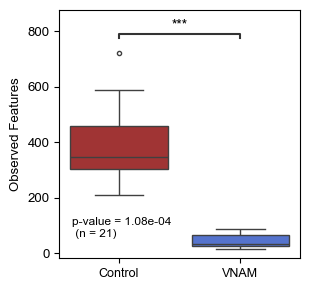

In [29]:
## Observed Features


data = df_observed
feat = data.columns[2]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['observed_features']  #Edit
VNAM = data[data['Group'] == 'VNAM']['observed_features']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-10, )
plt.ylabel('Observed Features', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
plt.legend([], [], title=label, loc='lower left',  #Edit
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('observed.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


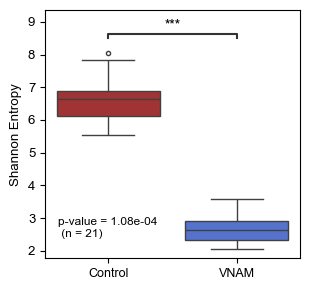

In [30]:
## Shannon Entropy


data = df_shannon
feat = data.columns[2]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['shannon_entropy']  #Edit
VNAM = data[data['Group'] == 'VNAM']['shannon_entropy']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(0, 175)
plt.ylabel('Shannon Entropy', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
plt.legend([], [], title=label, loc='lower left',  #Edit
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('shannon.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


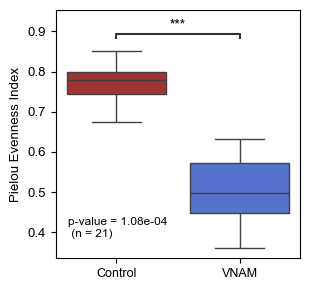

In [31]:
## pielou_e


data = df_pielou
feat = data.columns[2]  ## Group 열 의미함
orders = data.Group.unique()  ## Group 종류 의미함

Control = data[data['Group'] == 'Control']['pielou_evenness']  #Edit
VNAM = data[data['Group'] == 'VNAM']['pielou_evenness']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(0.6, )
plt.ylabel('Pielou Evenness Index', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('pielou.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


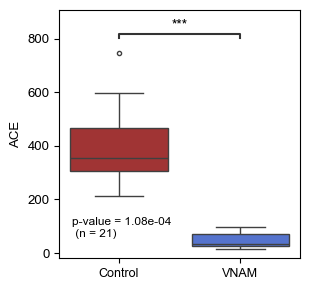

In [32]:
## ACE


data = df_ace
feat = data.columns[2]  ## Group 열 의미함
orders = data.Group.unique()  ## Group 종류 의미함

Control = data[data['Group'] == 'Control']['ace']  #Edit
VNAM = data[data['Group'] == 'VNAM']['ace']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')  ## 통계기법 설정 (AlphaDiv의 경우 Kruskal-Wallis가 default)
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)  ## plot에 표시될 그룹명을 바꿀 때 사용
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('ACE', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit: p-value 소수점 조절. 지수 형태로 나타내려면 f 대신 e 사용 (ex. {p:.2e})
plt.legend([], [], title=label, loc='lower left',  #Edit: loc 위치 적절하게 조절
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('ace.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


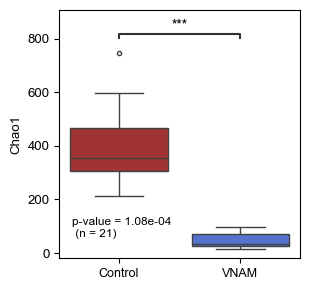

In [33]:
## Chao1


data = df_chao1
feat = data.columns[2]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['chao1']  #Edit
VNAM = data[data['Group'] == 'VNAM']['chao1']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(-100, )
plt.ylabel('Chao1', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
plt.legend([], [], title=label, loc='lower left',  #Edit
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('chao1.tiff', dpi=300, bbox_inches='tight')

Statistic: 15.00
P-value: 1.08e-04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Control vs. VNAM: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.075e-04 Stat=1.500e+01


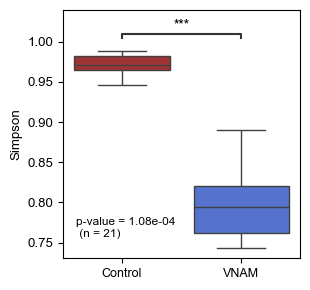

In [34]:
## Simpson


data = df_simpson
feat = data.columns[2]
orders = data.Group.unique()

from scipy.stats import kruskal

Control = data[data['Group'] == 'Control']['functools.partial(<function _simpsons_dominance at 0x75cdef3dc310>)']  #Edit
VNAM = data[data['Group'] == 'VNAM']['functools.partial(<function _simpsons_dominance at 0x75cdef3dc310>)']  #Edit


stat, p = kruskal(Control, VNAM)
print(f'Statistic: {stat:.2f}')
print(f'P-value: {p:.2e}')


palette = ['firebrick', 'royalblue']

plt.figure(figsize=(3.2, 3))
ax = sns.boxplot(data=data, x='Group', y=feat, palette=palette, fliersize=3)


pairs = [("Control", "VNAM")]  #Edit
annot = Annotator(ax, pairs, data=data,
                  x='Group', y=feat, order=orders)
annot.configure(test='Kruskal', text_format='star', loc='inside')
annot.apply_test()
annot.annotate()


#plt.xticks(['Control', 'VNAM'], ['Con', 'VNAM'],fontsize=9)
plt.xticks(orders, fontsize=9)
plt.yticks(fontsize=9.5)
plt.xticks(fontsize=9)
#plt.ylim(0, 175)
plt.ylabel('Simpson', fontsize=9.5)
plt.xlabel('')
plt.title('', fontsize=10.5, loc='left')

label = f'p-value = {p:.2e}\n (n = {data.shape[0]})'  #Edit
plt.legend([], [], title=label, loc='lower left',  #Edit
           frameon=False, title_fontsize=8.6)

plt.tight_layout()
#plt.savefig('simpson.tiff', dpi=300, bbox_inches='tight')